# Predictive Occupant Scheduling via Transformer-Based Forecasting

This notebook uses the LBNL Berkeley Office Building Dataset in doi_10_7941_D1N33Q__v20220202 to forecast future occupancy probability sequences for the south zones of Building 59.

The executed workflow is:

1. Load the full available occupancy-labeled period from LBNL Building 59.
2. Resample occupancy, WiFi, weather, temperature, and electricity data to 15-minute intervals.
3. Predict the next 24 hours of occupancy probability, i.e. 96 future intervals.
4. Compare rule-based, historical average, persistence, logistic regression, random forest, Transformer, TFT-lite, and PatchTST-lite models.
5. Report model-level, recommendation-level, and simplified energy-simulation metrics.

Important dataset note: occ.csv contains occupancy labels from 2018-05-22 07:00:00 to 2019-02-21 10:12:00. The notebook uses this full labeled period and aligns all other sensor streams to it. zone_co2.csv starts later than the occupancy labels, so CO2 is excluded automatically unless enough overlap exists.


In [1]:
import json
import math
import os
import random
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import Image, Markdown, display
from pandas.tseries.holiday import USFederalHolidayCalendar
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

@dataclass
class Config:
    data_dir: str = 'doi_10_7941_D1N33Q__v20220202/Building_59/Bldg59_clean data'
    figure_dir: str = 'figure'
    result_dir: str = 'result'
    freq: str = '15min'
    history_steps: int = 96
    horizon_steps: int = 96
    forecast_stride: int = 1
    train_fraction: float = 0.70
    val_fraction: float = 0.15
    recommend_empty_threshold: float = 0.35
    random_seed: int = 42
    rf_max_train_rows: int = 200_000
    rf_estimators: int = 50
    deep_epochs: int = 2
    early_stop_patience: int = 2
    batch_size: int = 256
    d_model: int = 32
    n_heads: int = 4
    n_layers: int = 1
    dropout: float = 0.10
    patch_len: int = 16
    patch_stride: int = 8
    hvac_savings_fraction: float = 0.30
    lighting_savings_fraction: float = 0.80
    emission_factor_kg_per_kwh: float = 0.20

cfg = Config()
Path(cfg.figure_dir).mkdir(exist_ok=True)
Path(cfg.result_dir).mkdir(exist_ok=True)

random.seed(cfg.random_seed)
np.random.seed(cfg.random_seed)
torch.manual_seed(cfg.random_seed)
torch.set_num_threads(min(8, os.cpu_count() or 1))

with open(Path(cfg.result_dir) / 'config.json', 'w', encoding='utf-8') as f:
    json.dump(asdict(cfg), f, indent=2)

print('Using torch', torch.__version__, 'device:', 'cuda' if torch.cuda.is_available() else 'cpu')
print('Forecast setup:', cfg.history_steps, 'past steps ->', cfg.horizon_steps, 'future steps at', cfg.freq)


Using torch 2.4.1+cpu device: cpu
Forecast setup: 96 past steps -> 96 future steps at 15min


In [2]:
def read_timeseries(path):
    df = pd.read_csv(path)
    if 'date' not in df.columns:
        df = df.rename(columns={df.columns[0]: 'date'})
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])
    df = df.loc[:, [c for c in df.columns if not str(c).startswith('Unnamed')]]
    for col in df.columns:
        if col != 'date':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.sort_values('date')


def resample_mean(df, freq):
    return df.set_index('date').sort_index().resample(freq).mean()


def time_features(index):
    minutes = index.hour * 60 + index.minute
    hour_angle = 2 * np.pi * minutes / (24 * 60)
    dow_angle = 2 * np.pi * index.dayofweek / 7
    month_angle = 2 * np.pi * (index.month - 1) / 12
    holidays = USFederalHolidayCalendar().holidays(index.min(), index.max())
    holiday_dates = pd.DatetimeIndex(holidays).normalize()
    out = pd.DataFrame(index=index)
    out['hour_sin'] = np.sin(hour_angle)
    out['hour_cos'] = np.cos(hour_angle)
    out['dow_sin'] = np.sin(dow_angle)
    out['dow_cos'] = np.cos(dow_angle)
    out['month_sin'] = np.sin(month_angle)
    out['month_cos'] = np.cos(month_angle)
    out['is_weekend'] = (index.dayofweek >= 5).astype(float)
    out['is_business_hour'] = ((index.dayofweek < 5) & (index.hour >= 7) & (index.hour < 19)).astype(float)
    out['is_holiday'] = index.normalize().isin(holiday_dates).astype(float)
    return out, list(out.columns)


def prepare_dataset(cfg):
    data_dir = Path(cfg.data_dir)
    occ_raw = read_timeseries(data_dir / 'occ.csv').set_index('date')
    occ_cols = [c for c in occ_raw.columns if c.startswith('occ_')]
    occ_raw['occ_count'] = occ_raw[occ_cols].sum(axis=1, min_count=1)
    occ = pd.DataFrame({
        'occ_count_mean': occ_raw['occ_count'].resample(cfg.freq).mean(),
        'occ_count_max': occ_raw['occ_count'].resample(cfg.freq).max(),
    })
    occ['occupied'] = (occ['occ_count_max'] > 0).astype(float)
    occ = occ.dropna(subset=['occ_count_mean', 'occupied']).sort_index()
    idx = occ.index

    features = occ.copy()
    source_rows = []

    def add_source(name, filename, build_cols):
        raw = read_timeseries(data_dir / filename)
        res = resample_mean(raw, cfg.freq).reindex(idx)
        before_cols = set(features.columns)
        build_cols(res)
        new_cols = [c for c in features.columns if c not in before_cols]
        coverage = 1.0 - features[new_cols].isna().mean().mean() if new_cols else 0.0
        source_rows.append({
            'source': name,
            'file': filename,
            'raw_rows': len(raw),
            'raw_start': raw['date'].min(),
            'raw_end': raw['date'].max(),
            'used_columns': ', '.join(new_cols) if new_cols else '(excluded)',
            'mean_coverage_before_fill': coverage,
        })

    def add_wifi(res):
        cols = [c for c in ['wifi_third_south', 'wifi_fourth_south'] if c in res.columns]
        features['wifi_south_total'] = res[cols].sum(axis=1, min_count=1)
        features['wifi_south_mean'] = res[cols].mean(axis=1)

    def add_weather(res):
        for col in ['air_temp_set_1', 'air_temp_set_2', 'dew_point_temperature_set_1d', 'relative_humidity_set_1', 'solar_radiation_set_1']:
            if col in res.columns:
                features[col] = res[col]

    def add_temp(res):
        features['temp_interior_mean'] = res.mean(axis=1)

    def add_ele(res):
        for col in ['mels_S', 'lig_S', 'hvac_S']:
            if col in res.columns:
                features[col] = res[col]
        present = [c for c in ['mels_S', 'lig_S', 'hvac_S'] if c in features.columns]
        features['ele_south_total'] = features[present].sum(axis=1, min_count=1)

    def add_co2(res):
        overlap = res.notna().any(axis=1).mean()
        if overlap >= 0.25:
            features['co2_mean'] = res.mean(axis=1)

    add_source('WiFi association counts', 'wifi.csv', add_wifi)
    add_source('site weather', 'site_weather.csv', add_weather)
    add_source('interior zone temperature', 'zone_temp_interior.csv', add_temp)
    add_source('south electrical meters', 'ele.csv', add_ele)
    add_source('zone CO2', 'zone_co2.csv', add_co2)

    time_df, time_cols = time_features(idx)
    features = pd.concat([features, time_df], axis=1)

    protected = {'occupied', 'occ_count_mean', 'occ_count_max'}
    feature_cols = [c for c in features.columns if c not in protected]
    missing_before_fill = features[feature_cols].isna().mean().rename('missing_before_fill')
    features[feature_cols] = features[feature_cols].interpolate(limit_direction='both')
    features[feature_cols] = features[feature_cols].ffill().bfill()
    features[feature_cols] = features[feature_cols].fillna(features[feature_cols].median())

    data_summary = pd.DataFrame([{
        'occupancy_raw_rows': len(occ_raw),
        'resampled_rows': len(features),
        'start': features.index.min(),
        'end': features.index.max(),
        'frequency': cfg.freq,
        'target': 'occupied = 1 if any south-zone count is greater than 0 in a 15-minute bin',
        'occupied_rate': features['occupied'].mean(),
        'mean_occupant_count': features['occ_count_mean'].mean(),
        'max_occupant_count': features['occ_count_max'].max(),
    }])

    feature_coverage = missing_before_fill.reset_index().rename(columns={'index': 'feature'})
    feature_coverage = feature_coverage.sort_values('missing_before_fill', ascending=False)
    feature_coverage['used_after_fill'] = True
    notes = pd.DataFrame([
        {'item': 'CO2', 'note': 'zone_co2.csv starts after the occupancy labels end, so CO2 is excluded unless at least 25 percent of the target window overlaps.'},
        {'item': 'Forecast target', 'note': 'Each forecast outputs 96 probabilities: one occupancy probability for each 15-minute interval over the next 24 hours.'},
        {'item': 'TFT-lite', 'note': 'This notebook trains a compact TFT-inspired model using historical observed inputs and known future time inputs; it is not the full pytorch-forecasting package implementation.'},
    ])
    return features, data_summary, pd.DataFrame(source_rows), feature_coverage, notes, time_cols


df, data_summary, source_coverage, feature_coverage, notes, time_cols = prepare_dataset(cfg)
df.to_csv(Path(cfg.result_dir) / 'processed_lbnl_15min.csv', encoding='utf-8-sig')
for name, table in {'data_summary': data_summary, 'source_coverage': source_coverage, 'feature_coverage': feature_coverage, 'notes': notes}.items():
    table.to_csv(Path(cfg.result_dir) / f'{name}.csv', index=False, encoding='utf-8-sig')

display(Markdown('## Data summary'))
display(data_summary)
display(Markdown('## Source coverage before filling'))
display(source_coverage)
display(Markdown('## Notes'))
display(notes)
print('Processed shape:', df.shape)


## Data summary

,occupancy_raw_rows,resampled_rows,start,end,frequency,target,occupied_rate,mean_occupant_count,max_occupant_count
0,396193,26413,2018-05-22 07:00:00,2019-02-21 10:00:00,15min,occupied = 1 if any south-zone count is greate...,0.688865,11.435999,123.0


## Source coverage before filling

,source,file,raw_rows,raw_start,raw_end,used_columns,mean_coverage_before_fill
0,WiFi association counts,wifi.csv,101047,2018-05-22 00:00:00,2020-12-31 23:55:00,"wifi_south_total, wifi_south_mean",0.184303
1,site weather,site_weather.csv,105217,2018-01-01 00:00:00,2021-01-01 00:00:00,"air_temp_set_1, air_temp_set_2, dew_point_temp...",1.000000
2,interior zone temperature,zone_temp_interior.csv,149696,2018-02-22 00:30:00,2021-01-01 00:00:00,temp_interior_mean,0.994435
3,south electrical meters,ele.csv,103048,2018-01-01 01:00:00,2021-01-01 00:00:00,"mels_S, lig_S, hvac_S, ele_south_total",0.919547
4,zone CO2,zone_co2.csv,565481,2019-08-19 01:33:00,2021-01-01 00:00:00,(excluded),0.000000


## Notes

,item,note
0,CO2,zone_co2.csv starts after the occupancy labels...
1,Forecast target,Each forecast outputs 96 probabilities: one oc...
2,TFT-lite,This notebook trains a compact TFT-inspired mo...


Processed shape: (26413, 24)


In [3]:
def make_splits(df, cfg):
    n = len(df)
    anchors = np.arange(cfg.history_steps - 1, n - cfg.horizon_steps, cfg.forecast_stride)
    train_end = int(n * cfg.train_fraction)
    val_end = int(n * (cfg.train_fraction + cfg.val_fraction))
    splits = {
        'train': anchors[anchors + cfg.horizon_steps < train_end],
        'val': anchors[(anchors >= train_end) & (anchors + cfg.horizon_steps < val_end)],
        'test': anchors[anchors >= val_end],
    }
    rows = []
    for name, a in splits.items():
        rows.append({
            'split': name,
            'anchor_count': len(a),
            'forecasted_intervals': len(a) * cfg.horizon_steps,
            'first_anchor': df.index[a[0]],
            'last_anchor': df.index[a[-1]],
            'first_target': df.index[a[0] + 1],
            'last_target': df.index[min(a[-1] + cfg.horizon_steps, len(df) - 1)],
        })
    return splits, pd.DataFrame(rows)


def future_positions(anchors, horizon_steps):
    return anchors[:, None] + np.arange(1, horizon_steps + 1)[None, :]


def safe_auc(y_true, prob):
    return float('nan') if len(np.unique(y_true)) < 2 else float(roc_auc_score(y_true, prob))


def safe_log_loss(y_true, prob):
    prob = np.clip(prob, 1e-6, 1 - 1e-6)
    return float('nan') if len(np.unique(y_true)) < 2 else float(log_loss(y_true, prob))


def model_metrics(name, y_true, prob):
    y = y_true.ravel().astype(int)
    p = np.clip(prob.ravel(), 1e-6, 1 - 1e-6)
    pred = (p >= 0.5).astype(int)
    return {
        'model': name,
        'recall': recall_score(y, pred, zero_division=0),
        'precision': precision_score(y, pred, zero_division=0),
        'f1': f1_score(y, pred, zero_division=0),
        'auroc': safe_auc(y, p),
        'auprc': average_precision_score(y, p),
        'brier': brier_score_loss(y, p),
        'log_loss': safe_log_loss(y, p),
    }


def recommendation_metrics(name, y_true, prob, threshold):
    y = y_true.ravel().astype(int)
    p = prob.ravel()
    recommend_empty = p < threshold
    actual_empty = y == 0
    actual_occupied = y == 1
    n_recs = int(recommend_empty.sum())
    return {
        'model': name,
        'empty_recommendation_threshold': threshold,
        'recommendation_rate': recommend_empty.mean(),
        'false_positive_recommendation_rate': ((recommend_empty & actual_occupied).sum() / n_recs if n_recs else 0.0),
        'missed_opportunity_rate': (((~recommend_empty) & actual_empty).sum() / actual_empty.sum() if actual_empty.sum() else 0.0),
        'comfort_conflict_rate': ((recommend_empty & actual_occupied).sum() / len(y) if len(y) else 0.0),
        'recommendation_count': n_recs,
    }


def rule_based_prob(df, positions):
    times = df.index.take(positions.ravel())
    occupied = (times.dayofweek < 5) & (times.hour >= 7) & (times.hour < 19)
    return np.where(occupied, 0.85, 0.10).reshape(positions.shape)


def historical_average_prob(df, train_end, positions):
    slot = df.index.dayofweek * 96 + df.index.hour * 4 + (df.index.minute // 15)
    train_table = pd.Series(df['occupied'].iloc[:train_end].to_numpy(), index=slot[:train_end]).groupby(level=0).mean()
    global_mean = df['occupied'].iloc[:train_end].mean()
    future_slots = slot[positions.ravel()]
    probs = np.array([train_table.get(s, global_mean) for s in future_slots], dtype=np.float32)
    return probs.reshape(positions.shape)


def persistence_yesterday_prob(df, positions, cfg):
    target = df['occupied'].to_numpy(np.float32)
    return target[positions - cfg.horizon_steps]


def rolling_mean_at_anchors(arr, anchors, window):
    csum = np.concatenate([[0.0], np.cumsum(arr, dtype=np.float64)])
    return ((csum[anchors + 1] - csum[anchors + 1 - window]) / window).astype(np.float32)


def make_tabular_arrays(df, anchors, cfg, future_time_cols, anchor_sensor_cols):
    target = df['occupied'].to_numpy(np.float32)
    count = df['occ_count_mean'].to_numpy(np.float32)
    pos = future_positions(anchors, cfg.horizon_steps)
    n = len(anchors)
    h = cfg.horizon_steps
    future_time = df[future_time_cols].to_numpy(np.float32)[pos.ravel()]
    future_steps = np.tile(np.arange(1, h + 1, dtype=np.float32), n).reshape(-1, 1) / h
    same_time_yesterday = target[(pos - cfg.horizon_steps).ravel()].reshape(-1, 1)
    blocks = [
        np.repeat(target[anchors].reshape(-1, 1), h, axis=0),
        np.repeat(count[anchors].reshape(-1, 1), h, axis=0),
        np.repeat(rolling_mean_at_anchors(target, anchors, 4).reshape(-1, 1), h, axis=0),
        np.repeat(rolling_mean_at_anchors(target, anchors, 16).reshape(-1, 1), h, axis=0),
        np.repeat(rolling_mean_at_anchors(target, anchors, 96).reshape(-1, 1), h, axis=0),
        np.repeat(rolling_mean_at_anchors(count, anchors, 96).reshape(-1, 1), h, axis=0),
    ]
    names = ['anchor_last_occupied', 'anchor_last_count', 'hist_occ_mean_1h', 'hist_occ_mean_4h', 'hist_occ_mean_24h', 'hist_count_mean_24h']
    if anchor_sensor_cols:
        anchor_sensor = df[anchor_sensor_cols].to_numpy(np.float32)[anchors]
        blocks.append(np.repeat(anchor_sensor, h, axis=0))
        names.extend([f'anchor_{c}' for c in anchor_sensor_cols])
    x = np.concatenate(blocks + [same_time_yesterday, future_steps, future_time], axis=1)
    names += ['same_time_yesterday', 'horizon_fraction'] + future_time_cols
    y = target[pos.ravel()].astype(int)
    return x.astype(np.float32), y, names


def stratified_sample_indices(y, max_rows, seed):
    if len(y) <= max_rows:
        return np.arange(len(y))
    rng = np.random.default_rng(seed)
    pos = np.flatnonzero(y == 1)
    neg = np.flatnonzero(y == 0)
    pos_n = min(len(pos), max_rows // 2)
    neg_n = min(len(neg), max_rows - pos_n)
    idx = np.concatenate([rng.choice(pos, size=pos_n, replace=False), rng.choice(neg, size=neg_n, replace=False)])
    if len(idx) < max_rows:
        pool = np.setdiff1d(np.arange(len(y)), idx)
        idx = np.concatenate([idx, rng.choice(pool, size=max_rows - len(idx), replace=False)])
    rng.shuffle(idx)
    return idx

splits, split_summary = make_splits(df, cfg)
split_summary.to_csv(Path(cfg.result_dir) / 'split_summary.csv', index=False, encoding='utf-8-sig')
display(Markdown('## Chronological train/validation/test split'))
display(split_summary)


## Chronological train/validation/test split

,split,anchor_count,forecasted_intervals,first_anchor,last_anchor,first_target,last_target
0,train,18298,1756608,2018-05-23 06:45:00,2018-11-29 21:00:00,2018-05-23 07:00:00,2018-11-30 21:00:00
1,val,3866,371136,2018-11-30 21:15:00,2019-01-10 03:30:00,2018-11-30 21:30:00,2019-01-11 03:30:00
2,test,3866,371136,2019-01-11 03:45:00,2019-02-20 10:00:00,2019-01-11 04:00:00,2019-02-21 10:00:00


In [4]:
start_classical = time.time()
train_end = int(len(df) * cfg.train_fraction)
target = df['occupied'].to_numpy(np.float32)
test_positions = future_positions(splits['test'], cfg.horizon_steps)
y_test = target[test_positions].astype(int)
predictions = {}

predictions['Rule-based schedule'] = rule_based_prob(df, test_positions)
predictions['Historical average'] = historical_average_prob(df, train_end, test_positions)
predictions['Persistence yesterday'] = persistence_yesterday_prob(df, test_positions, cfg)

anchor_sensor_cols = [c for c in [
    'wifi_south_total', 'wifi_south_mean', 'temp_interior_mean', 'air_temp_set_1',
    'relative_humidity_set_1', 'solar_radiation_set_1', 'mels_S', 'lig_S', 'hvac_S', 'ele_south_total'
] if c in df.columns]

x_train, y_train, tabular_feature_names = make_tabular_arrays(df, splits['train'], cfg, time_cols, anchor_sensor_cols)
x_test, _, _ = make_tabular_arrays(df, splits['test'], cfg, time_cols, anchor_sensor_cols)

logistic = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SGDClassifier(
        loss='log_loss', penalty='l2', alpha=1e-4, max_iter=1000, tol=1e-3,
        class_weight='balanced', random_state=cfg.random_seed, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=5,
    )),
])
logistic.fit(x_train, y_train)
predictions['Logistic regression'] = logistic.predict_proba(x_test)[:, 1].reshape(len(splits['test']), -1)

rf_idx = stratified_sample_indices(y_train, cfg.rf_max_train_rows, cfg.random_seed)
rf = RandomForestClassifier(
    n_estimators=cfg.rf_estimators, max_depth=14, min_samples_leaf=20,
    max_features='sqrt', class_weight='balanced_subsample', n_jobs=-1,
    random_state=cfg.random_seed,
)
rf.fit(x_train[rf_idx], y_train[rf_idx])
predictions['Random forest'] = rf.predict_proba(x_test)[:, 1].reshape(len(splits['test']), -1)

feature_sets = pd.DataFrame({'tabular_feature': tabular_feature_names})
feature_sets.to_csv(Path(cfg.result_dir) / 'tabular_feature_set.csv', index=False, encoding='utf-8-sig')

print('Classical models finished in %.1f seconds' % (time.time() - start_classical))
print('Tabular training rows:', x_train.shape[0], 'features:', x_train.shape[1])
del x_train, y_train, x_test


Classical models finished in 15.0 seconds
Tabular training rows: 1756608 features: 27


In [5]:
class ForecastWindowDataset(Dataset):
    def __init__(self, hist_values, future_values, target, anchors, cfg):
        self.hist_values = hist_values
        self.future_values = future_values
        self.target = target
        self.anchors = anchors
        self.cfg = cfg

    def __len__(self):
        return len(self.anchors)

    def __getitem__(self, idx):
        anchor = self.anchors[idx]
        hist_start = anchor - self.cfg.history_steps + 1
        hist_end = anchor + 1
        future_start = anchor + 1
        future_end = anchor + self.cfg.horizon_steps + 1
        return (
            torch.from_numpy(self.hist_values[hist_start:hist_end]),
            torch.from_numpy(self.future_values[future_start:future_end]),
            torch.from_numpy(self.target[future_start:future_end].astype(np.float32)),
        )


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        position = torch.arange(max_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class SequenceTransformer(nn.Module):
    def __init__(self, n_hist, n_future, cfg):
        super().__init__()
        self.hist_proj = nn.Linear(n_hist, cfg.d_model)
        self.future_proj = nn.Linear(n_future, cfg.d_model)
        self.pos = PositionalEncoding(cfg.d_model, max_len=max(cfg.history_steps, cfg.horizon_steps) + 8)
        layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model, nhead=cfg.n_heads, dim_feedforward=cfg.d_model * 4,
            dropout=cfg.dropout, batch_first=True, activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=cfg.n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(cfg.d_model * 2), nn.Linear(cfg.d_model * 2, cfg.d_model),
            nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(cfg.d_model, 1),
        )

    def forward(self, x_hist, x_future):
        enc = self.encoder(self.pos(self.hist_proj(x_hist)))
        context = enc[:, -1, :]
        future = self.future_proj(x_future)
        context = context.unsqueeze(1).expand(-1, x_future.size(1), -1)
        return self.head(torch.cat([context, future], dim=-1)).squeeze(-1)


class PatchTSTLite(nn.Module):
    def __init__(self, n_hist, n_future, cfg):
        super().__init__()
        self.patch_len = cfg.patch_len
        self.patch_stride = cfg.patch_stride
        self.patch_proj = nn.Linear(n_hist * cfg.patch_len, cfg.d_model)
        self.future_proj = nn.Linear(n_future, cfg.d_model)
        n_patches = 1 + (cfg.history_steps - cfg.patch_len) // cfg.patch_stride
        self.pos = PositionalEncoding(cfg.d_model, max_len=max(n_patches, cfg.horizon_steps) + 8)
        layer = nn.TransformerEncoderLayer(
            d_model=cfg.d_model, nhead=cfg.n_heads, dim_feedforward=cfg.d_model * 4,
            dropout=cfg.dropout, batch_first=True, activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=cfg.n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(cfg.d_model * 2), nn.Linear(cfg.d_model * 2, cfg.d_model),
            nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(cfg.d_model, 1),
        )

    def forward(self, x_hist, x_future):
        patches = x_hist.unfold(dimension=1, size=self.patch_len, step=self.patch_stride)
        patches = patches.contiguous().view(patches.size(0), patches.size(1), -1)
        enc = self.encoder(self.pos(self.patch_proj(patches)))
        context = enc.mean(dim=1)
        future = self.future_proj(x_future)
        context = context.unsqueeze(1).expand(-1, x_future.size(1), -1)
        return self.head(torch.cat([context, future], dim=-1)).squeeze(-1)


class TFTLite(nn.Module):
    def __init__(self, n_hist, n_future, cfg):
        super().__init__()
        self.hist_proj = nn.Sequential(nn.Linear(n_hist, cfg.d_model), nn.GELU(), nn.LayerNorm(cfg.d_model))
        self.future_proj = nn.Sequential(nn.Linear(n_future, cfg.d_model), nn.GELU(), nn.LayerNorm(cfg.d_model))
        self.encoder_lstm = nn.LSTM(cfg.d_model, cfg.d_model, batch_first=True)
        self.decoder_lstm = nn.LSTM(cfg.d_model, cfg.d_model, batch_first=True)
        self.attn = nn.MultiheadAttention(cfg.d_model, cfg.n_heads, dropout=cfg.dropout, batch_first=True)
        self.gate = nn.Sequential(nn.Linear(cfg.d_model * 2, cfg.d_model), nn.Sigmoid())
        self.norm = nn.LayerNorm(cfg.d_model)
        self.head = nn.Sequential(nn.Linear(cfg.d_model, cfg.d_model), nn.GELU(), nn.Dropout(cfg.dropout), nn.Linear(cfg.d_model, 1))

    def forward(self, x_hist, x_future):
        hist = self.hist_proj(x_hist)
        future = self.future_proj(x_future)
        enc, state = self.encoder_lstm(hist)
        dec, _ = self.decoder_lstm(future, state)
        memory = torch.cat([enc, dec], dim=1)
        attn_out, _ = self.attn(dec, memory, memory)
        gate = self.gate(torch.cat([dec, attn_out], dim=-1))
        fused = self.norm(dec + gate * attn_out)
        return self.head(fused).squeeze(-1)


def loader_loss(model, loader, criterion, device):
    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for x_hist, x_future, y in loader:
            x_hist = x_hist.to(device)
            x_future = x_future.to(device)
            y = y.to(device)
            loss = criterion(model(x_hist, x_future), y)
            total += float(loss.item()) * len(y)
            n += len(y)
    return total / max(n, 1)


def train_deep_model(name, model, train_ds, val_ds, pos_weight, cfg, device):
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight, dtype=torch.float32, device=device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    best_state = None
    best_val = float('inf')
    stale = 0
    rows = []
    for epoch in range(1, cfg.deep_epochs + 1):
        model.train()
        running = 0.0
        count = 0
        for x_hist, x_future, y in train_loader:
            x_hist = x_hist.to(device)
            x_future = x_future.to(device)
            y = y.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x_hist, x_future), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += float(loss.item()) * len(y)
            count += len(y)
        train_loss = running / max(count, 1)
        val_loss = loader_loss(model, val_loader, criterion, device)
        rows.append({'model': name, 'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
        print(f'{name} epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')
        if val_loss < best_val - 1e-4:
            best_val = val_loss
            stale = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            stale += 1
            if stale >= cfg.early_stop_patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(rows)


def predict_deep(model, dataset, cfg, device):
    loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=0)
    model.eval()
    parts = []
    with torch.no_grad():
        for x_hist, x_future, _ in loader:
            logits = model(x_hist.to(device), x_future.to(device))
            parts.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(parts, axis=0)


In [6]:
hist_feature_cols = [c for c in df.columns if c != 'occ_count_max']
hist_values = df[hist_feature_cols].to_numpy(np.float32)
train_mask = np.arange(len(df)) < train_end
hist_mean = hist_values[train_mask].mean(axis=0, keepdims=True)
hist_std = hist_values[train_mask].std(axis=0, keepdims=True)
hist_std[hist_std < 1e-6] = 1.0
hist_scaled = ((hist_values - hist_mean) / hist_std).astype(np.float32)
future_values = df[time_cols].to_numpy(np.float32)

train_ds = ForecastWindowDataset(hist_scaled, future_values, target, splits['train'], cfg)
val_ds = ForecastWindowDataset(hist_scaled, future_values, target, splits['val'], cfg)
test_ds = ForecastWindowDataset(hist_scaled, future_values, target, splits['test'], cfg)
train_y = target[future_positions(splits['train'], cfg.horizon_steps).ravel()]
pos = max(train_y.sum(), 1.0)
neg = max(len(train_y) - train_y.sum(), 1.0)
pos_weight = float(np.clip(neg / pos, 0.25, 8.0))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

start_deep = time.time()
train_histories = []
for name, model in [
    ('Transformer', SequenceTransformer(len(hist_feature_cols), len(time_cols), cfg)),
    ('TFT-lite', TFTLite(len(hist_feature_cols), len(time_cols), cfg)),
    ('PatchTST-lite', PatchTSTLite(len(hist_feature_cols), len(time_cols), cfg)),
]:
    trained, hist = train_deep_model(name, model, train_ds, val_ds, pos_weight, cfg, device)
    train_histories.append(hist)
    predictions[name] = predict_deep(trained, test_ds, cfg, device)

training_history = pd.concat(train_histories, ignore_index=True)
training_history.to_csv(Path(cfg.result_dir) / 'training_history.csv', index=False, encoding='utf-8-sig')
print('Deep models finished in %.1f seconds' % (time.time() - start_deep))


Transformer epoch 1: train_loss=0.3444, val_loss=0.4190


Transformer epoch 2: train_loss=0.2709, val_loss=0.3887


TFT-lite epoch 1: train_loss=0.3084, val_loss=0.3426


TFT-lite epoch 2: train_loss=0.1913, val_loss=0.4274


PatchTST-lite epoch 1: train_loss=0.3370, val_loss=0.4280


PatchTST-lite epoch 2: train_loss=0.2416, val_loss=0.4157


Deep models finished in 58.4 seconds


In [7]:
def simulate_energy(df, anchors, predictions, y_true, cfg):
    positions = future_positions(anchors, cfg.horizon_steps)
    hvac = df['hvac_S'].to_numpy(np.float32) if 'hvac_S' in df.columns else np.zeros(len(df), dtype=np.float32)
    lighting = df['lig_S'].to_numpy(np.float32) if 'lig_S' in df.columns else np.zeros(len(df), dtype=np.float32)
    avoidable_kw = cfg.hvac_savings_fraction * np.clip(hvac[positions], 0, None) + cfg.lighting_savings_fraction * np.clip(lighting[positions], 0, None)
    avoidable_kwh = avoidable_kw * 0.25
    actual_empty = y_true == 0
    total_empty_kwh = float((avoidable_kwh * actual_empty).sum())
    rows = []
    for name, prob in predictions.items():
        rec = prob < cfg.recommend_empty_threshold
        safe = rec & actual_empty
        conflict = rec & (~actual_empty)
        safe_kwh = float((avoidable_kwh * safe).sum())
        rows.append({
            'model': name,
            'daily_schedule_windows': len(anchors),
            'raw_recommended_kwh': float((avoidable_kwh * rec).sum()),
            'energy_after_false_positives_kwh': safe_kwh,
            'false_positive_energy_risk_kwh': float((avoidable_kwh * conflict).sum()),
            'available_empty_window_kwh': total_empty_kwh,
            'safe_energy_capture_rate': safe_kwh / total_empty_kwh if total_empty_kwh else 0.0,
            'emission_avoided_kg_co2e': safe_kwh * cfg.emission_factor_kg_per_kwh,
            'comfort_conflict_rate': conflict.sum() / rec.sum() if rec.sum() else 0.0,
        })
    return pd.DataFrame(rows)

model_metrics_df = pd.DataFrame([model_metrics(name, y_test, prob) for name, prob in predictions.items()])
model_metrics_df = model_metrics_df.sort_values('auprc', ascending=False).reset_index(drop=True)
rec_metrics_df = pd.DataFrame([recommendation_metrics(name, y_test, prob, cfg.recommend_empty_threshold) for name, prob in predictions.items()])
rec_metrics_df = rec_metrics_df.sort_values('false_positive_recommendation_rate').reset_index(drop=True)

test_anchor_times = df.index.take(splits['test'])
sim_mask = (test_anchor_times.hour == 0) & (test_anchor_times.minute == 0)
if sim_mask.sum() == 0:
    sim_mask = np.zeros(len(splits['test']), dtype=bool)
    sim_mask[::cfg.horizon_steps] = True
sim_indices = np.flatnonzero(sim_mask)
sim_anchors = splits['test'][sim_indices]
sim_y = target[future_positions(sim_anchors, cfg.horizon_steps)].astype(int)
sim_predictions = {name: prob[sim_indices] for name, prob in predictions.items()}
sim_metrics_df = simulate_energy(df, sim_anchors, sim_predictions, sim_y, cfg).sort_values('energy_after_false_positives_kwh', ascending=False).reset_index(drop=True)

best_model = model_metrics_df.iloc[0]['model']
best_prob = predictions[best_model]
long_positions = test_positions.ravel()
best_long = pd.DataFrame({
    'anchor_time': np.repeat(df.index.take(splits['test']).to_numpy(), cfg.horizon_steps),
    'target_time': df.index.take(long_positions).to_numpy(),
    'horizon_step': np.tile(np.arange(1, cfg.horizon_steps + 1), len(splits['test'])),
    'actual_occupied': y_test.ravel().astype(int),
    'predicted_probability': best_prob.ravel(),
})
best_long['recommend_empty'] = best_long['predicted_probability'] < cfg.recommend_empty_threshold

model_metrics_df.to_csv(Path(cfg.result_dir) / 'model_metrics.csv', index=False, encoding='utf-8-sig')
rec_metrics_df.to_csv(Path(cfg.result_dir) / 'recommendation_metrics.csv', index=False, encoding='utf-8-sig')
sim_metrics_df.to_csv(Path(cfg.result_dir) / 'simulation_metrics.csv', index=False, encoding='utf-8-sig')
best_long.to_csv(Path(cfg.result_dir) / 'test_forecast_probabilities_best_model.csv', index=False, encoding='utf-8-sig')

run_summary = pd.DataFrame([{
    'best_model_by_auprc': best_model,
    'test_forecast_intervals': int(y_test.size),
    'test_forecast_anchors': int(len(splits['test'])),
    'daily_simulation_windows': int(len(sim_anchors)),
    'device': str(device),
    'result_dir': cfg.result_dir,
    'figure_dir': cfg.figure_dir,
}])
run_summary.to_csv(Path(cfg.result_dir) / 'run_summary.csv', index=False, encoding='utf-8-sig')

display(Markdown('## Model-level metrics'))
display(model_metrics_df)
display(Markdown('## Recommendation-level metrics'))
display(rec_metrics_df)
display(Markdown('## Simulator-level metrics'))
display(sim_metrics_df)
display(Markdown('## Run summary'))
display(run_summary)


## Model-level metrics

,model,recall,precision,f1,auroc,auprc,brier,log_loss
0,Random forest,0.895656,0.932750,0.913827,0.936213,0.972584,0.097874,0.325845
1,Historical average,0.876364,0.921893,0.898552,0.918948,0.957099,0.103590,0.345771
2,TFT-lite,0.819284,0.904377,0.859730,0.888894,0.953687,0.131814,0.412841
3,Transformer,0.865449,0.863168,0.864307,0.885605,0.951651,0.126086,0.390855
4,PatchTST-lite,0.926258,0.829051,0.874963,0.875047,0.948528,0.131028,0.397043
5,Logistic regression,0.916072,0.805419,0.857189,0.844022,0.929249,0.140848,0.428464
6,Persistence yesterday,0.821816,0.821334,0.821575,0.690057,0.801831,0.254108,3.508968
7,Rule-based schedule,0.351047,0.711957,0.470234,0.500066,0.711906,0.454743,1.315867


## Recommendation-level metrics

,model,empty_recommendation_threshold,recommendation_rate,false_positive_recommendation_rate,missed_opportunity_rate,comfort_conflict_rate,recommendation_count
0,Historical average,0.35,0.228978,0.148278,0.323112,0.033953,84982
1,Transformer,0.35,0.141943,0.151993,0.582230,0.021574,52680
2,Random forest,0.35,0.231958,0.164506,0.327367,0.038159,86088
3,PatchTST-lite,0.35,0.097514,0.172640,0.719981,0.016835,36191
4,Logistic regression,0.35,0.103183,0.179501,0.706159,0.018522,38295
5,TFT-lite,0.35,0.278911,0.293487,0.316070,0.081857,103514
6,Persistence yesterday,0.35,0.287703,0.440891,0.441701,0.126846,106777
7,Rule-based schedule,0.35,0.648991,0.711837,0.350915,0.461976,240864


## Simulator-level metrics

,model,daily_schedule_windows,raw_recommended_kwh,energy_after_false_positives_kwh,false_positive_energy_risk_kwh,available_empty_window_kwh,safe_energy_capture_rate,emission_avoided_kg_co2e,comfort_conflict_rate
0,Random forest,40,642.976318,548.711243,94.265045,786.923828,0.697286,109.742249,0.193648
1,TFT-lite,40,803.541382,529.384705,274.156677,786.923828,0.672727,105.876941,0.294063
2,Historical average,40,635.183899,518.622681,116.561287,786.923828,0.659051,103.724536,0.148358
3,Persistence yesterday,40,1074.176514,473.853546,600.322998,786.923828,0.602159,94.770709,0.441839
4,Rule-based schedule,40,2743.562500,411.795837,2331.767090,786.923828,0.523298,82.359167,0.710337
5,Transformer,40,374.109741,306.290649,67.819069,786.923828,0.389225,61.258130,0.192063
6,Logistic regression,40,253.255402,211.504333,41.751087,786.923828,0.268774,42.300867,0.160112
7,PatchTST-lite,40,233.566376,205.767303,27.799078,786.923828,0.261483,41.153461,0.110169


## Run summary

,best_model_by_auprc,test_forecast_intervals,test_forecast_anchors,daily_simulation_windows,device,result_dir,figure_dir
0,Random forest,371136,3866,40,cpu,result,figure


## Saved figures

**figure/deep_training_curves.png**

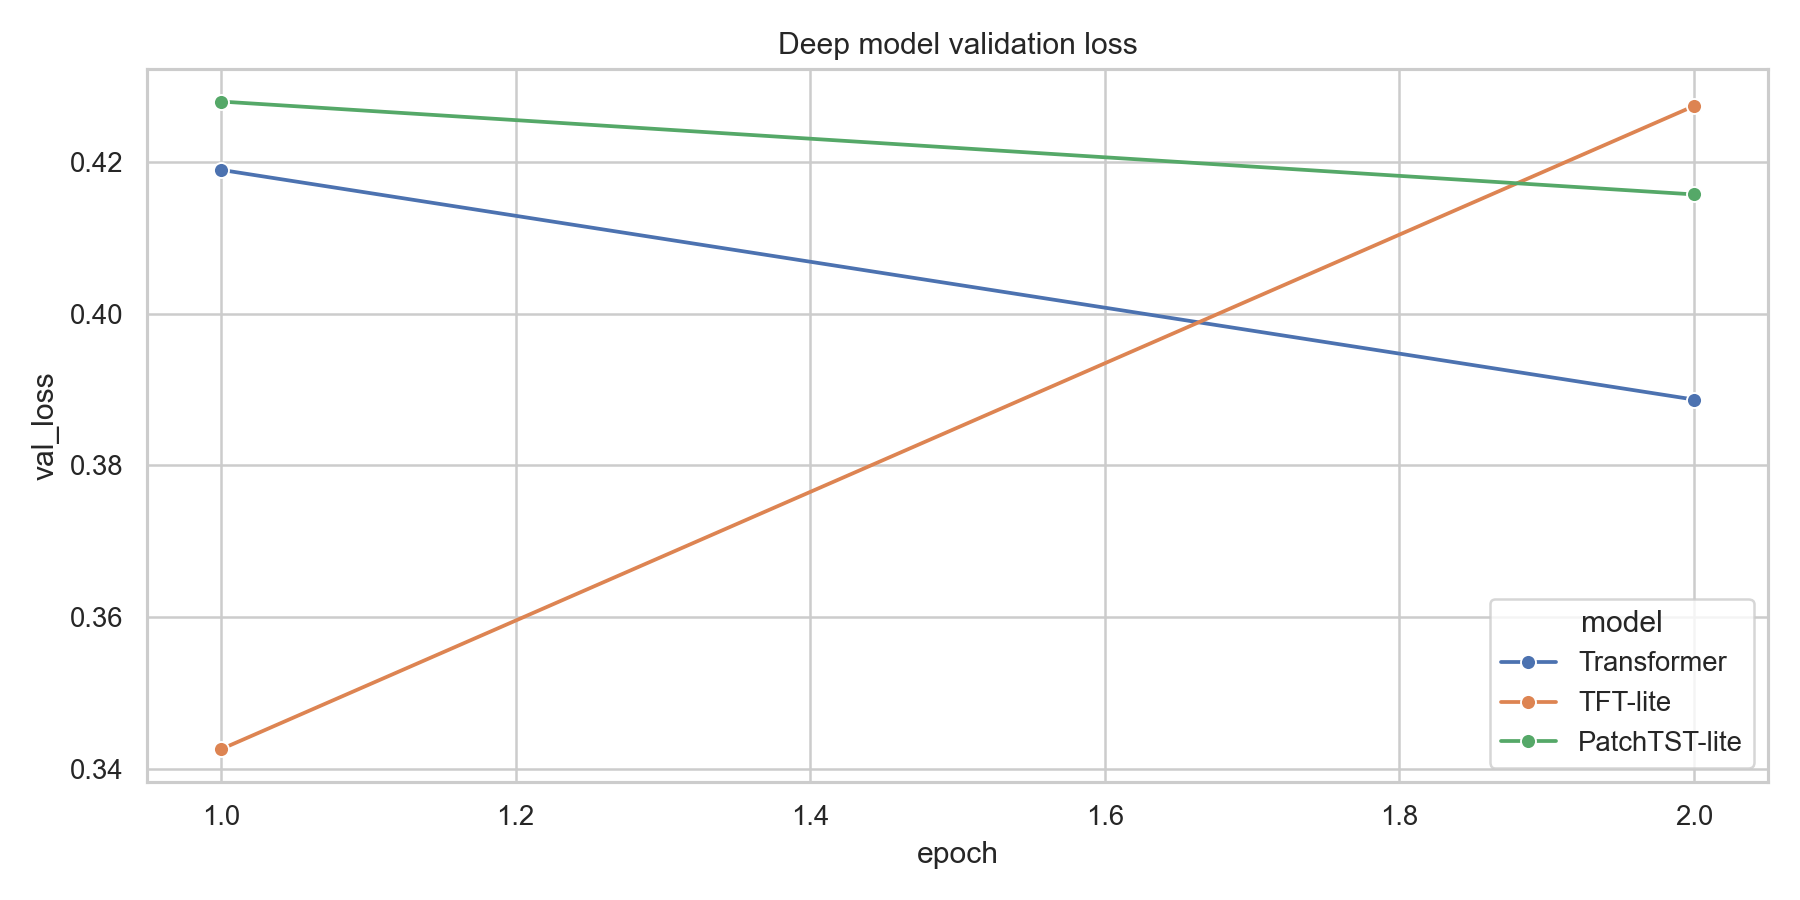

**figure/example_24h_forecast.png**

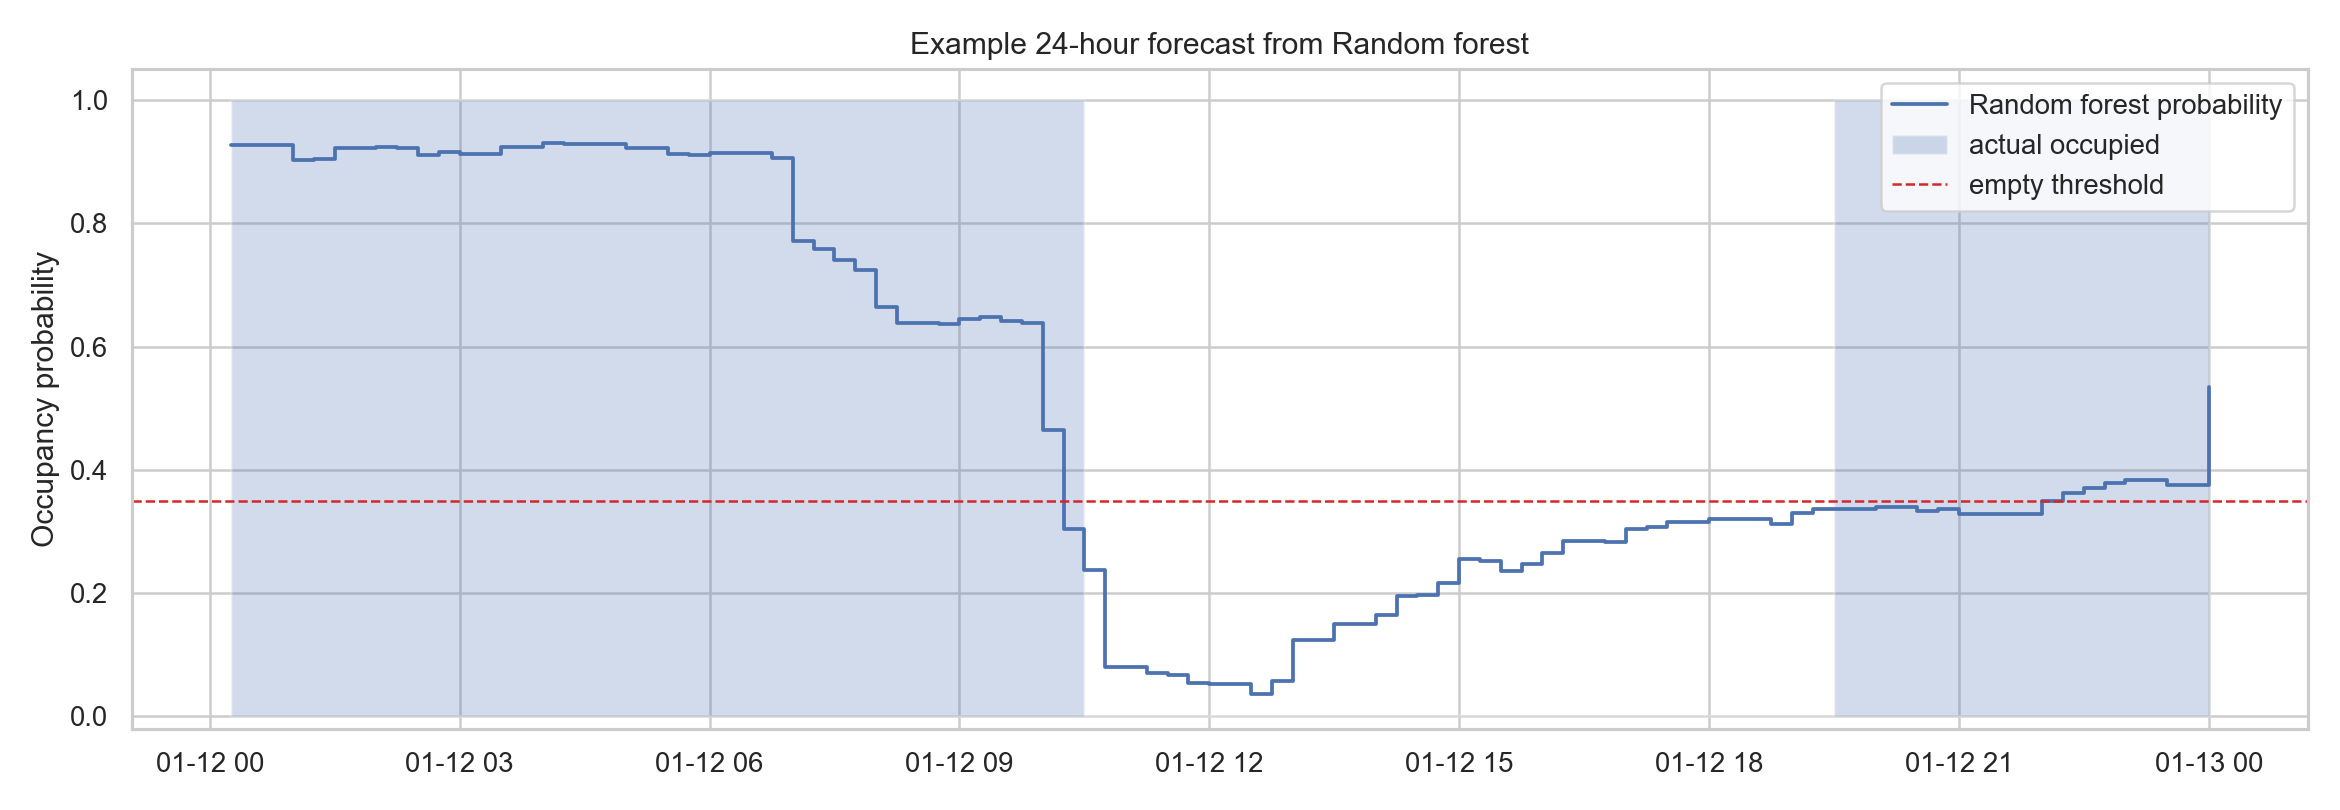

**figure/model_metrics_bar.png**

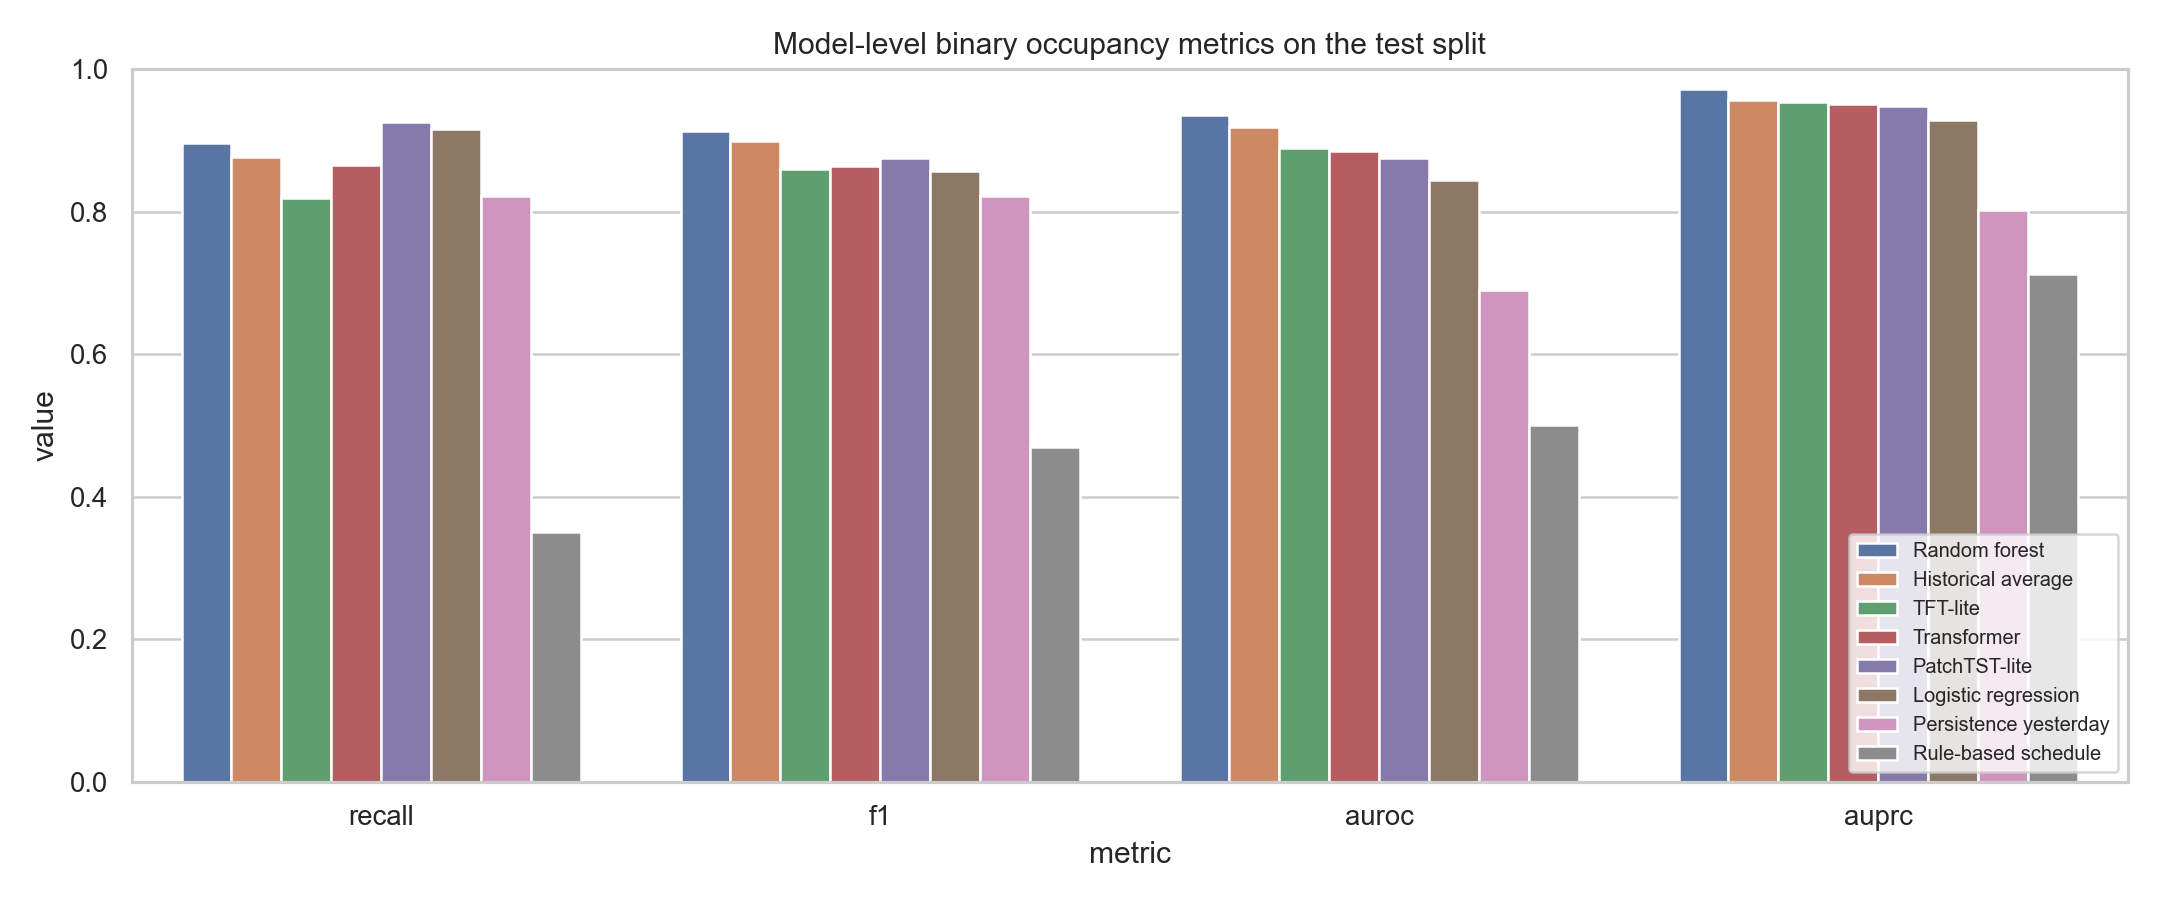

**figure/occupancy_profile_heatmap.png**

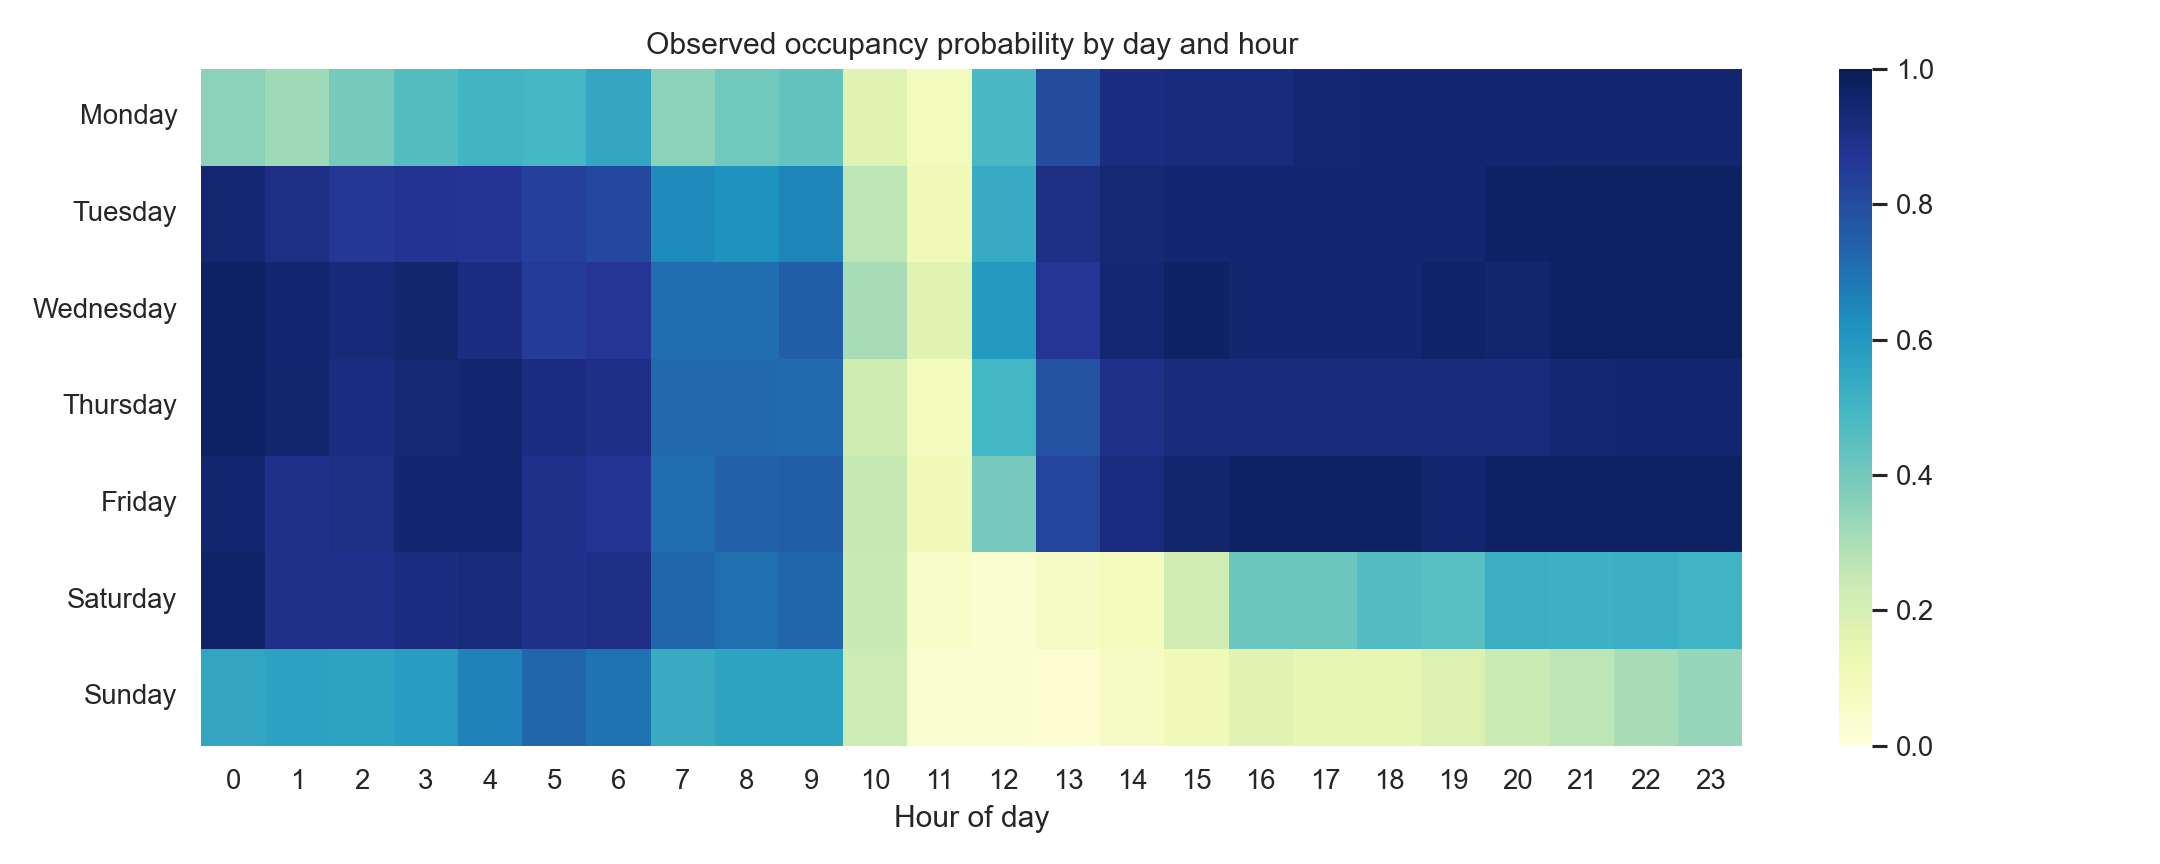

**figure/recommendation_metrics_bar.png**

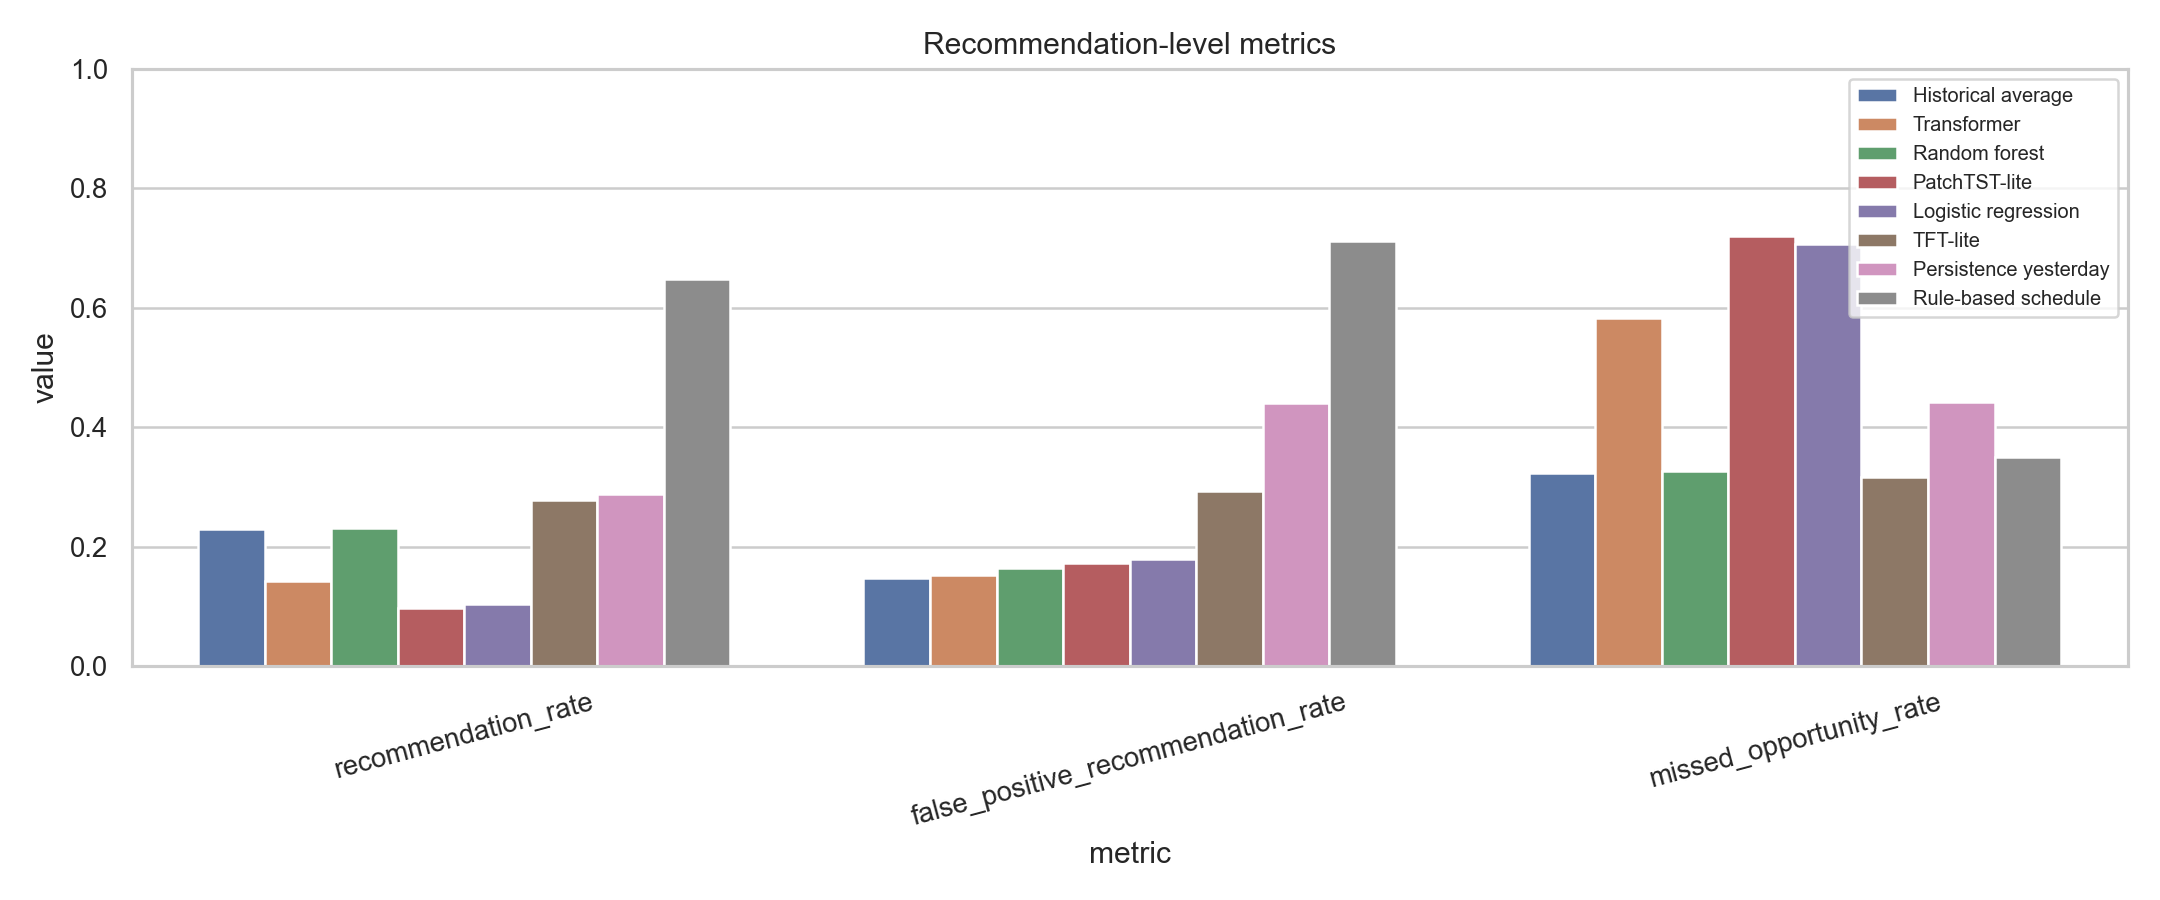

**figure/simulation_energy_bar.png**

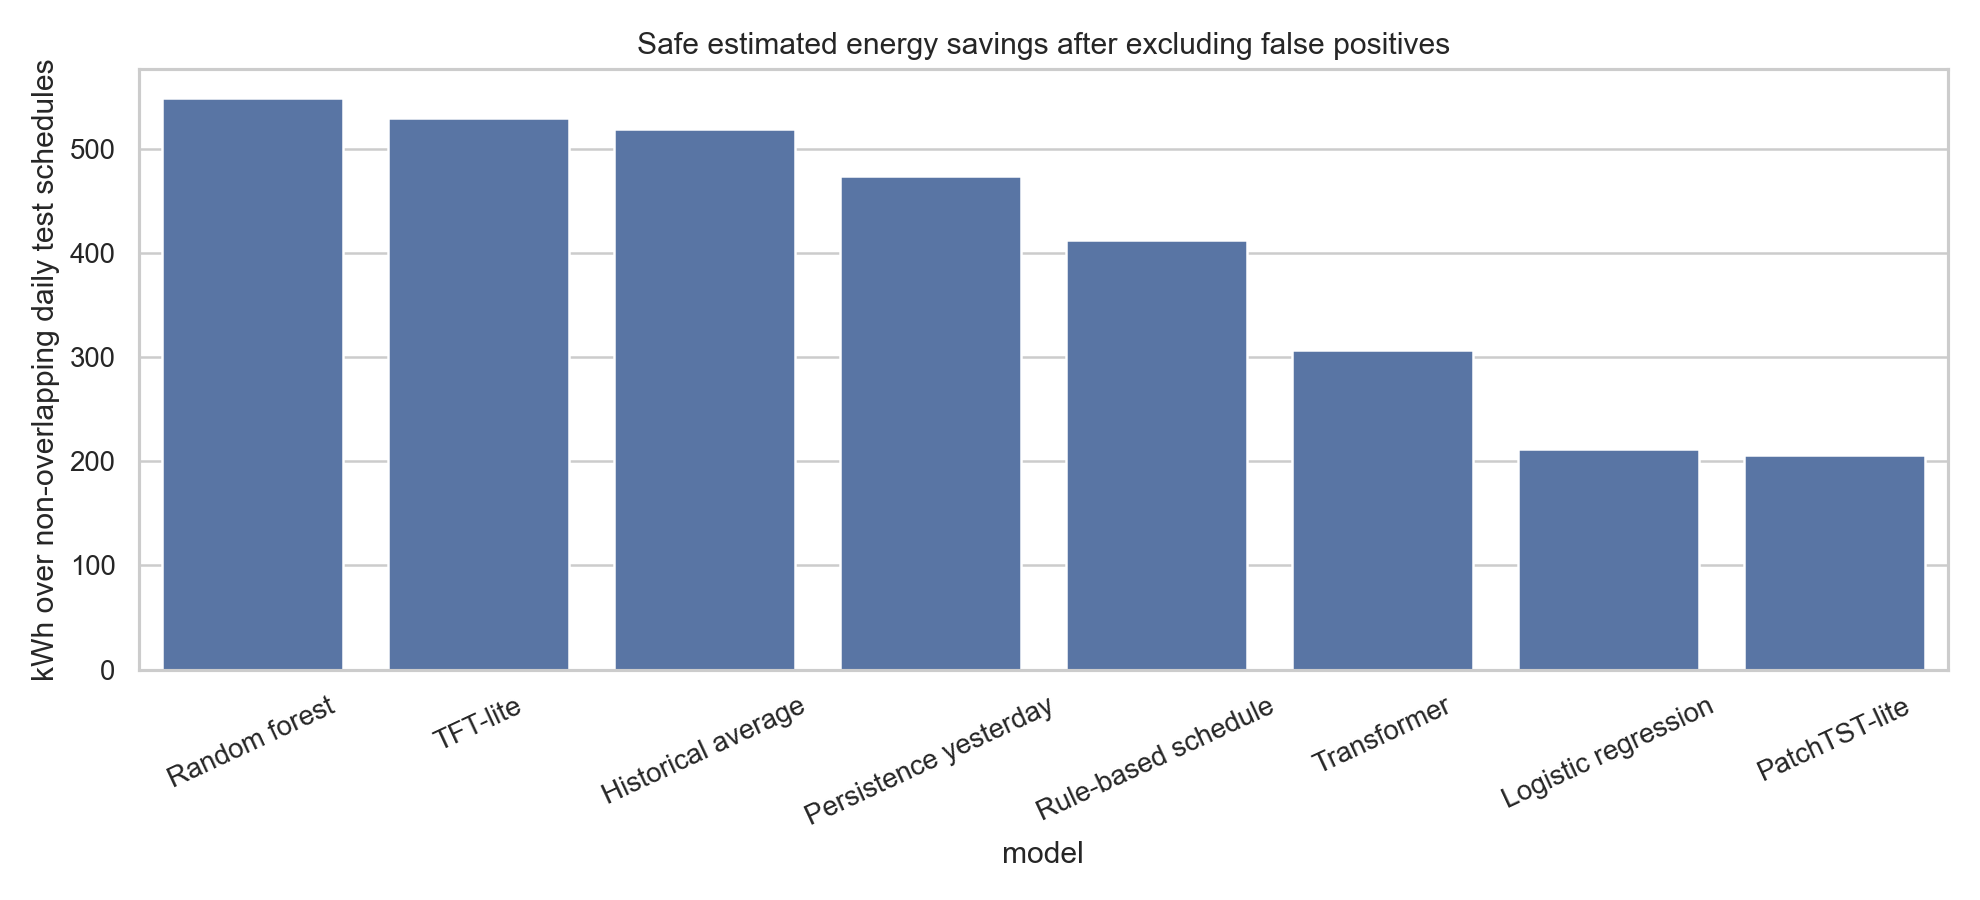

Saved result CSV files:
- result/data_summary.csv
- result/example_24h_forecast.csv
- result/feature_coverage.csv
- result/model_metrics.csv
- result/notes.csv
- result/processed_lbnl_15min.csv
- result/recommendation_metrics.csv
- result/run_summary.csv
- result/simulation_metrics.csv
- result/source_coverage.csv
- result/split_summary.csv
- result/tabular_feature_set.csv
- result/test_forecast_probabilities_best_model.csv
- result/training_history.csv


In [8]:
def save_fig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=180)
    plt.close()

# Occupancy profile heatmap.
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
profile = df.assign(day=df.index.day_name(), hour=df.index.hour).groupby(['day', 'hour'])['occupied'].mean().unstack('hour').reindex(day_order)
plt.figure(figsize=(12, 4.8))
sns.heatmap(profile, cmap='YlGnBu', vmin=0, vmax=1)
plt.title('Observed occupancy probability by day and hour')
plt.xlabel('Hour of day')
plt.ylabel('')
save_fig(Path(cfg.figure_dir) / 'occupancy_profile_heatmap.png')

# Model metrics.
plt.figure(figsize=(12, 5))
metric_long = model_metrics_df.melt(id_vars='model', value_vars=['recall', 'f1', 'auroc', 'auprc'], var_name='metric', value_name='value')
sns.barplot(data=metric_long, x='metric', y='value', hue='model')
plt.ylim(0, 1)
plt.title('Model-level binary occupancy metrics on the test split')
plt.legend(loc='lower right', fontsize=8)
save_fig(Path(cfg.figure_dir) / 'model_metrics_bar.png')

# Recommendation metrics.
plt.figure(figsize=(12, 5))
rec_long = rec_metrics_df.melt(
    id_vars='model',
    value_vars=['recommendation_rate', 'false_positive_recommendation_rate', 'missed_opportunity_rate'],
    var_name='metric', value_name='value',
)
sns.barplot(data=rec_long, x='metric', y='value', hue='model')
plt.ylim(0, 1)
plt.title('Recommendation-level metrics')
plt.xticks(rotation=15)
plt.legend(loc='upper right', fontsize=8)
save_fig(Path(cfg.figure_dir) / 'recommendation_metrics_bar.png')

# Simulation energy.
plt.figure(figsize=(11, 5))
sns.barplot(data=sim_metrics_df, x='model', y='energy_after_false_positives_kwh')
plt.xticks(rotation=25)
plt.title('Safe estimated energy savings after excluding false positives')
plt.ylabel('kWh over non-overlapping daily test schedules')
save_fig(Path(cfg.figure_dir) / 'simulation_energy_bar.png')

# Training curves.
plt.figure(figsize=(10, 5))
sns.lineplot(data=training_history, x='epoch', y='val_loss', hue='model', marker='o')
plt.title('Deep model validation loss')
save_fig(Path(cfg.figure_dir) / 'deep_training_curves.png')

# Example 24-hour probability sequence.
example_idx = int(sim_indices[0]) if len(sim_indices) else 0
example_anchor = splits['test'][example_idx]
example_pos = future_positions(np.array([example_anchor]), cfg.horizon_steps)[0]
example = pd.DataFrame({
    'date': df.index.take(example_pos),
    'actual_occupied': df['occupied'].to_numpy()[example_pos],
    f'{best_model}_probability': predictions[best_model][example_idx],
})
example.to_csv(Path(cfg.result_dir) / 'example_24h_forecast.csv', index=False, encoding='utf-8-sig')

plt.figure(figsize=(13, 4.5))
plt.step(example['date'], example[f'{best_model}_probability'], where='post', label=f'{best_model} probability')
plt.fill_between(example['date'], 0, example['actual_occupied'], step='post', alpha=0.25, label='actual occupied')
plt.axhline(cfg.recommend_empty_threshold, color='tab:red', linestyle='--', linewidth=1, label='empty threshold')
plt.ylim(-0.02, 1.05)
plt.title(f'Example 24-hour forecast from {best_model}')
plt.ylabel('Occupancy probability')
plt.legend(loc='upper right')
save_fig(Path(cfg.figure_dir) / 'example_24h_forecast.png')

figure_files = sorted(Path(cfg.figure_dir).glob('*.png'))
display(Markdown('## Saved figures'))
for p in figure_files:
    display(Markdown(f'**{p.as_posix()}**'))
    display(Image(filename=str(p)))

print('Saved result CSV files:')
for p in sorted(Path(cfg.result_dir).glob('*.csv')):
    print('-', p.as_posix())
